In [2]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [3]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [7]:
# 画像を読み込み
x_train = np.load('CT_Train_NoBed.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

# 新しいボリュームのサイズ (各軸を半分にする)
new_shape = tuple([dim // 2 for dim in x_train.shape[1:]])

# サイズを半分に縮小
x_train_resized = np.zeros((x_train.shape[0], *new_shape))  # 新しい形に合わせて初期化

for i in range(x_train.shape[0]):
    # 各画像を縮小
    x_train_resized[i] = scipy.ndimage.zoom(x_train[i], (0.5, 0.5, 0.5), order=3)
print('Resized train vol_shape:', x_train_resized.shape[1:])
print('Resized train shape:', x_train_resized.shape)
x_train = x_train_resized

Resized train vol_shape: (64, 128, 128)
Resized train shape: (400, 64, 128, 128)


In [8]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [9]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 64, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 64, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 64, 128, 128])
Zero Gradient Shape: (2, 64, 128, 128, 3)


In [56]:
a = 1
b = 0.2

mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l1').loss

def total_loss(y_true, y_pred, y_vec):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(None, y_vec)
    return a * mse + b * grad, mse, grad

In [57]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [58]:
model3D_3 = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
6
7
64
128
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
11
11
11
[32, 64, 64]


In [59]:
from tqdm.notebook import tqdm

# エポック数と最小ロスの設定
epochs = 2000

# ロスや他のメトリクスを記録するリスト
losses = []
mses = []
grads = []

for epoch in tqdm(range(epochs)):

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32).to(device)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D_3(moving_images, fixed_images)

    # 損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image, Vec)
    # loss = mse_loss(fixed_images, transformed_image)

    # 逆伝播
    loss.backward()
    optimizer.step()

    # モデルを保存
    torch.save(model3D_3.state_dict(), 'model_VXM_3D_MInoBed_gradkakunin.pth')

    # エポックごとのロスを保存
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, mse: {mse:.4f}, grad: {grad:.4f}")
    # print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_11068\3888942195.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)
C:\Users\user\AppData\Local\Temp\ipykernel_11068\3888942195.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32).to(device)


torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 1/2000, Loss: 0.0202, mse: 0.0202, grad: 0.0000
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 2/2000, Loss: 0.0581, mse: 0.0581, grad: 0.0000
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 3/2000, Loss: 0.0296, mse: 0.0296, grad: 0.0000
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 4/2000, Loss: 0.0250, mse: 0.0250, grad: 0.0000
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 5/2000, Loss: 0.0272, mse: 0.0272, grad: 0.0000
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 6/2000, Loss: 0.0400, mse: 0.0400, grad: 0.0000
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 7/2000, Loss: 0.0248, mse: 0.0248, grad: 0.0001
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 8/2000, Loss: 0.0277, mse: 0.0277, grad: 0.0001
torch.Size([2, 3, 64, 128, 128])
torch.S

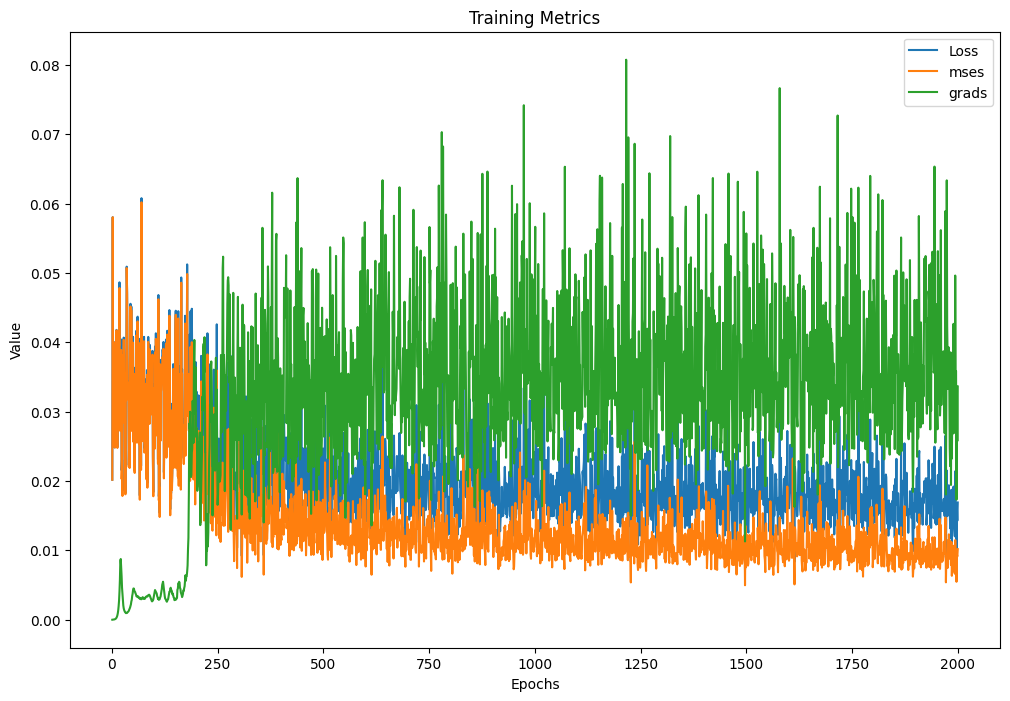

In [60]:
import torch
import numpy as np
import matplotlib.pyplot as plt
epochs_range = range(1, epoch + 1)  # `epoch + 2` を `epoch + 1` に変更

# 損失、MSE、勾配をプロット
epochs_range = range(1,  epoch+2)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, mses, label='mses')
plt.plot(epochs_range, grads, label='grads')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
# model3D_7.to(device)
# optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
# model3D_7.load_state_dict(torch.load('model_VXM_3D_duwl_omomi_kakunin2.pth', map_location=device))

CT1 = np.load('No13_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No13_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7 = model3D_3
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)

    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)    

    # moving_images2 = transformer(moving_images, displacement_field)
    transformed_image, Vec = model3D_3(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = Vec[0].cpu().numpy()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])


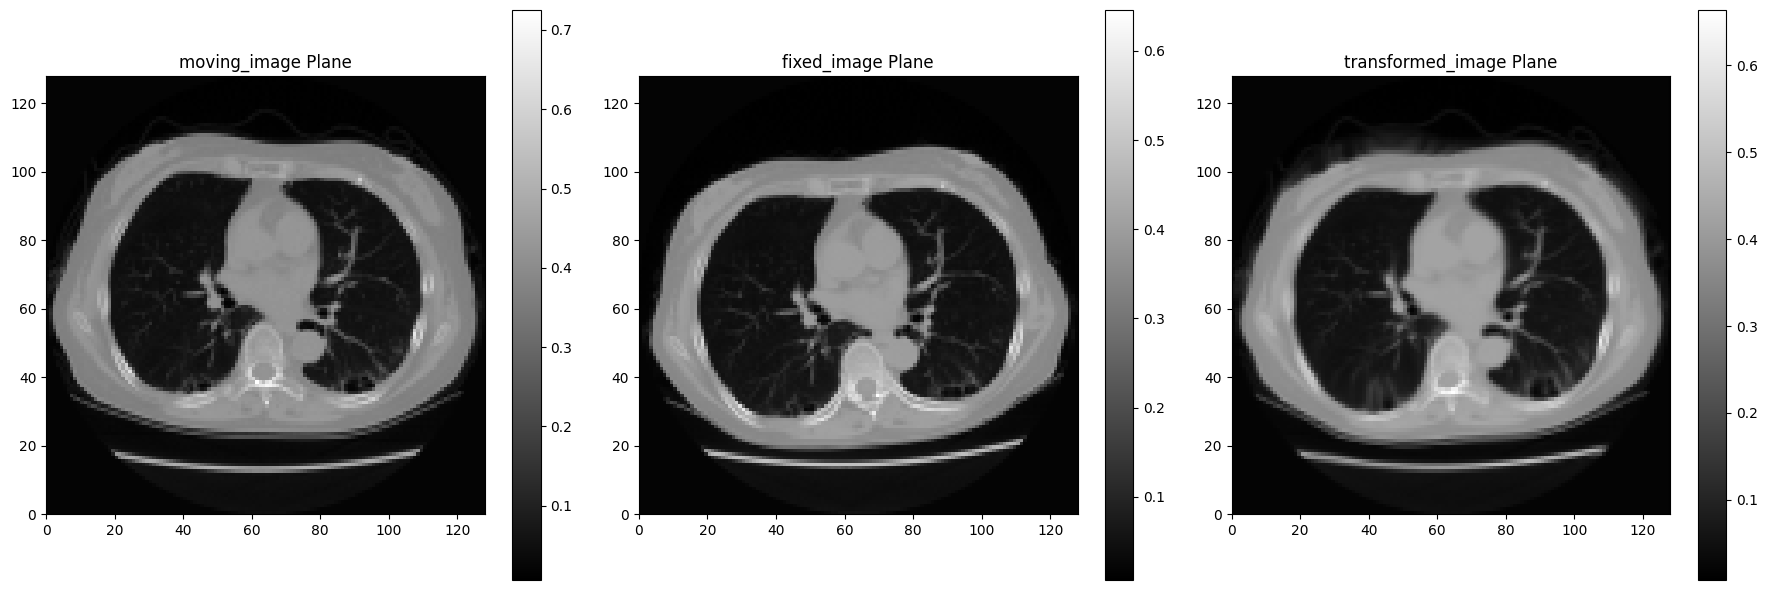

In [63]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 30

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()
